In [1]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from shared.model_params import shift, lag_size, n_clusters

In [2]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit, LeaveOneGroupOut, GroupKFold
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator, RegressorMixin
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
import sqlite3
conn = sqlite3.connect("dataset.db")

In [16]:
df = pd.read_sql("SELECT * FROM runs_stats WHERE game_ind < 3 AND country IN ('AFG', 'USA', 'FRA')", conn)

In [17]:
df

,date,gdp,population,gdp_per_cap,money_activity,consuption,supply,industrial_level,subside_percent,rentability,...,most_popular_party,flag_name,war_status,prom_innov,comm_innov,rich_tax,middle_tax,poor_tax,country,game_ind
0,1836.7.1,87.0,4003480.0,2.173,27.970,69.0,214.0,0.00,0.00,0.0,...,Консерватизм,AFG_monarchy,0.0,0.0,0.0,3.234060,1.544699,16.698194,AFG,1
1,1837.1.1,97.0,4005616.0,2.422,14.218,49.0,211.0,0.00,0.00,0.0,...,Консерватизм,AFG_monarchy,0.0,0.0,0.0,3.433588,2.813846,17.066556,AFG,1
2,1837.7.1,89.0,4010144.0,2.219,8.118,47.0,202.0,0.00,0.00,0.0,...,Консерватизм,AFG_monarchy,0.0,0.0,0.0,3.391833,3.002497,16.605946,AFG,1
3,1838.1.1,108.0,4014848.0,2.690,4.636,82.0,248.0,0.00,0.00,0.0,...,Консерватизм,AFG_monarchy,0.0,0.0,0.0,3.484397,5.419284,18.013493,AFG,1
4,1838.7.1,100.0,4018272.0,2.489,2.331,79.0,242.0,0.00,0.00,0.0,...,Консерватизм,AFG_monarchy,0.0,0.0,0.0,3.440317,3.086313,18.108327,AFG,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,1904.1.1,12612.0,46598576.0,27.065,7.686,17591.0,30658.0,0.09,40.34,-9.5,...,Консерватизм,USA_republic,0.0,48.0,34.0,562.143549,466.861517,6057.057576,USA,2
836,1904.7.1,12252.0,47202596.0,25.956,10.640,16760.0,30093.0,0.07,46.22,-8.4,...,Консерватизм,USA_republic,0.0,48.0,34.0,408.863317,497.634163,6039.429528,USA,2
837,1905.1.1,13273.0,47831680.0,27.749,31.892,17834.0,30982.0,0.08,42.02,-12.3,...,Консерватизм,USA_republic,0.0,48.0,34.0,515.429381,520.455808,6432.469228,USA,2
838,1905.7.1,13585.0,48447364.0,28.041,12.832,17411.0,32300.0,0.09,31.93,-4.9,...,Консерватизм,USA_republic,0.0,48.0,38.0,505.629992,607.026278,6361.716734,USA,2


In [78]:
class DataLoader:
    def __init__(self, countries, max_count = (0, 5), shift_size = 4, lag_size = 6, logging = True):
        self.countries = countries
        self.max_count = max_count
        self.shift_size = shift_size
        self.lag_size = lag_size
        self.logging = logging

    def get_datasets(self, folder_path):
        all_x = []
        all_y = []
        group_ids = []
        file_counter = 0
        for country in self.countries:
            for count in range(*self.max_count):
                path = folder_path + f"{country}_{count}.csv"
                try:
                    df = pd.read_csv(path)
                    target = df["gdp"].ffill().bfill().shift(-self.shift_size).dropna()
                    features = df.iloc[:len(target)].copy()
                    features["group_id"] = file_counter
                    all_x.append(features)
                    all_y.extend(target.tolist())
                    group_ids.extend([file_counter] * len(target))
                    file_counter += 1
                except Exception as e:
                    if self.logging:
                        print(f"Ошибка в {path}: {e}")
        data = pd.concat(all_x, ignore_index=True)
        data["war_status"] = data["war_status"].astype(int)
        
        return data, np.array(all_y), np.array(group_ids)
    
    def prepare_target(self, y):
        return np.log1p(y)
    
    
    @staticmethod
    def _generate_period_names(data):
        bins = [0, 1850, 1862, 1873, 1885, 1895, 1906, np.inf]
        labels = [
            '1836-1850',
            '1851-1862', 
            '1863-1873', 
            '1874-1885', 
            '1886-1895', 
            '1896-1906', 
            '1907+'
        ]
        year = pd.to_datetime(data["date"]).dt.year
        name = data["flag_name"].str.split("_").str[0]
        periods = pd.cut(year, bins=bins, labels=labels)
        return name + " (" + periods.astype(str) + ")"

    
    def add_name(self, data):
        data["name"] = self._generate_period_names(data)
        return data

    def add_new_cols(self, arr):
        res = []
        for col in arr:
            for i in range(1, self.lag_size + 1):
                res.append(f"{col}_log_diff_{i}")
            res.append(f"{col}_rolling_mean_3")
            res.append(f"{col}_rolling_std_5")
        return res
    
    def cluster_cols(self, num):
        res = []
        for i in range(num):
            res.append(f"dist_to_c{i+1}")
        return res

In [79]:
class DataProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, num_cols, important_cols, lag_size):
        self.num_cols = num_cols
        self.important_cols = important_cols
        self.lag_size = lag_size

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        new_cols = {}
        X["gdp"] = X["gdp"].bfill().ffill()
        X["gdp"] = np.log1p(X["gdp"])
        X["tax_progressivity"] = X["rich_tax"] - X["poor_tax"]
        X["innovation_total"] = X["prom_innov"] + X["comm_innov"]
        for col in self.num_cols:
            X[col] = X[col].bfill().ffill().astype(float)
        for col in self.important_cols:
            for i in range(1, self.lag_size + 1):
                new_cols[f"{col}_log_diff_{i}"] = np.log1p(X[col]).diff(i)
            new_cols[f"{col}_rolling_mean_3"] = X[col].rolling(3).mean()
            new_cols[f"{col}_rolling_std_5"] = X[col].rolling(5).std()
        X = pd.concat([X, pd.DataFrame(new_cols, index=X.index)], axis=1)
        return X.ffill().bfill()
    
class DataSelector(BaseEstimator, TransformerMixin):
    def __init__(self, all_cols):
        self.all_cols = all_cols
    
    def fit(self, X, y = None):
        return self
    
    def transform(self, X):
        return X[self.all_cols]
    

class ClusterPredictor(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=5, features_for_clustering=None):
        self.n_clusters = n_clusters
        self.features_for_clustering = features_for_clustering
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)

    def fit(self, X, y=None):
        x_subset = X[self.features_for_clustering]
        x_scaled = self.scaler.fit_transform(x_subset)
        self.kmeans.fit(x_scaled)
        return self

    def transform(self, X):
        X = X.copy()
        x_subset = X[self.features_for_clustering]
        x_scaled = self.scaler.transform(x_subset)
        cluster_distances = self.kmeans.transform(x_scaled)
        df_clust = pd.DataFrame(
            cluster_distances, 
            columns=[f"dist_to_c{i + 1}" for i in range(self.n_clusters)],
            index=X.index
        )
        X["cluster"] = self.kmeans.predict(x_scaled)
        X["cluster"] = X["cluster"].astype(str)

        X = pd.concat([X, df_clust], axis=1)
        
        return X

    def get_scaler(self):
        return self.scaler

In [80]:
loader = DataLoader(["ENG", "RUS", "AUS", "CHI", "BEL", "PRU", "SWE", "FRA", "ETH", "TUR", "SIC", "MEX", "AFG", "PER", "POR", "USA"], (1, 6), shift_size=shift, lag_size=lag_size, logging=False)

In [81]:
cat_cols = ["most_popular_party", "war_status", "cluster"]
num_cols = ["money_activity", "subside_percent", "rentability", "diversification", "gdp_per_cap", "gdp_per_reg",\
             "country_savings", "bank_savings", "population_savings", "money_mass", "all_employemenent", "all_free_work_places", "fabric_worker_salary",\
             "capitalist_salary", "literacy", "military_budget", "naval_budget", "army_innov", "naval_innov", "country_size", "population_per_reg",\
             "rich_tax", "middle_tax", "poor_tax", "prom_innov", "comm_innov", "tax_progressivity", "innovation_total"]

important_cols = ["gdp", "poor_tax", "bank_savings", "population"]
im_cols = ["poor_tax", "bank_savings", "population"]
new_num_cols = loader.add_new_cols(im_cols)
deleted_cols = ["industrial_level", "subside_pct", "gold_income", "goverement"]
all_cols = cat_cols + num_cols + new_num_cols + loader.cluster_cols(3)
cluster_cols = ["money_activity", "rentability", "diversification", "literacy", "prom_innov", "comm_innov", "innovation_total", "tax_progressivity", "subside_percent", "fabric_worker_salary",\
                "capitalist_salary", "population_per_reg"]

In [82]:
data, y, groups = loader.get_datasets("data/")
y = loader.prepare_target(y)

In [83]:
pipe = Pipeline([
    ("Data_prepare", DataProcessor(num_cols, important_cols, lag_size=lag_size)),
    ("Clusterisation", ClusterPredictor(n_clusters=3, features_for_clustering=cluster_cols)),
    ("Data_select", DataSelector(all_cols)),
    ("Model", CatBoostRegressor(
        iterations=1000,   
        learning_rate=0.01,
        depth=3,         
        l2_leaf_reg=3,   
        verbose=50,
        cat_features=cat_cols,
        early_stopping_rounds=50
    ))
])

In [84]:
pipe.fit(data, y)

0:	learn: 1.5493626	total: 14.8ms	remaining: 14.8s
50:	learn: 1.0475771	total: 831ms	remaining: 15.5s
100:	learn: 0.7382873	total: 1.67s	remaining: 14.9s
150:	learn: 0.5512173	total: 2.49s	remaining: 14s
200:	learn: 0.4422686	total: 3.54s	remaining: 14.1s
250:	learn: 0.3807841	total: 4.82s	remaining: 14.4s
300:	learn: 0.3465399	total: 5.69s	remaining: 13.2s
350:	learn: 0.3273545	total: 6.49s	remaining: 12s
400:	learn: 0.3158150	total: 7.26s	remaining: 10.8s
450:	learn: 0.3086241	total: 8.01s	remaining: 9.75s
500:	learn: 0.3039719	total: 8.75s	remaining: 8.72s
550:	learn: 0.3002498	total: 9.56s	remaining: 7.79s
600:	learn: 0.2972270	total: 10.3s	remaining: 6.84s
650:	learn: 0.2945329	total: 11.1s	remaining: 5.93s
700:	learn: 0.2921186	total: 11.8s	remaining: 5.04s
750:	learn: 0.2897566	total: 12.6s	remaining: 4.17s
800:	learn: 0.2876718	total: 13.4s	remaining: 3.33s
850:	learn: 0.2857265	total: 14.2s	remaining: 2.48s
900:	learn: 0.2837105	total: 15s	remaining: 1.64s
950:	learn: 0.281846

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Data_prepare', ...), ('Clusterisation', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,num_cols,"['money_activity', 'subside_percent', ...]"
,important_cols,"['gdp', 'poor_tax', ...]"
,lag_size,12
,n_clusters,3
,features_for_clustering,"['money_activity', 'rentability', ...]"
,all_cols,"['most_popular_party', 'war_status', ...]"


In [85]:
test_loader = DataLoader(["RUS"], (1,6), shift_size=shift)
test, y_test, _ = test_loader.get_datasets("data/")
y_test = loader.prepare_target(y_test)

Ошибка в data/RUS_5.csv: [Errno 2] No such file or directory: 'data/RUS_5.csv'


In [86]:
test_prepared = pipe.named_steps["Data_prepare"].transform(test)
y_baseline = np.expm1(
    test_prepared["gdp"] + test_prepared["gdp_log_diff_1"] * shift
).to_numpy()

In [87]:
prediction = pipe.predict(test)

In [88]:
class Stats:
    def __init__(self, pipe, data):
        self.pipe = pipe
        self.cluster = pipe.named_steps["Clusterisation"]
        self.model = pipe.named_steps["Model"]
        self.data = data
        self.tscv = TimeSeriesSplit(n_splits=5, gap = loader.shift_size)

    def model_score(self):
        y_true = self.data["gdp"].ffill().bfill()
        y_pred = self.pipe.predict(self.data)
        y_pred = np.expm1(y_pred)
        print(f"MAE: {mean_absolute_error(y_true, y_pred)}")
        print(f"MSE: {mean_squared_error(y_true, y_pred)}")
        print(f"RMSE: {root_mean_squared_error(y_true, y_pred)}")
        return
    
    def get_clusters_info(self, mode = "normal", scaler: StandardScaler = None):
        '''modes:
            1. normal - вывод списка стран и кластеров
            2. percent - вывод вероятности страны попадания в конкретный кластер
            3. explain - выводит центральные нормализированные значения каждого кластера
            4. hard_explain - выводит центральные ненормализованные значения каждого кластера
            5. lite_explain - менее подробно, но красиво выводит смыслы кластеров'''
        X = loader.add_name(self.data.copy())
        X_prepared = self.pipe.named_steps["Data_prepare"].transform(X)
        X_prepared["name"] = X["name"].values
        match mode:
            case "normal":
                X_grouped = (
                    X_prepared.groupby("name")[cluster_cols]
                    .mean()
                    .reset_index()
                )
                X_clustered = self.cluster.transform(X_grouped)
                for cluster, group in X_clustered.groupby("cluster"):
                    print(f"\nCluster {int(cluster)+1} ({len(group)} элементов):")
                    for n in group["name"]:
                        print(n, end=" ")

            case "percent":
                X_clustered = self.cluster.transform(X_prepared)
                grouped_pct = (
                    X_clustered
                    .groupby("name")["cluster"]
                    .value_counts(normalize=True)
                    .unstack(fill_value=0)
                )
                print(grouped_pct)

            case "explain":
                centers = self.cluster.kmeans.cluster_centers_
                centers_df = pd.DataFrame(centers, columns=cluster_cols)
                print(centers_df)

            case "hard_explain":
                centers = self.cluster.kmeans.cluster_centers_
                centers_df = pd.DataFrame(centers, columns=cluster_cols)
                centers_df = scaler.inverse_transform(centers_df)
                print(centers_df)
            
            case "lite_explain":
                centers = self.cluster.kmeans.cluster_centers_
                centers_df = pd.DataFrame(centers, columns=cluster_cols)
                cluster_descriptions = centers_df.apply(self.describe_cluster, axis=1)
                for i, desc in enumerate(cluster_descriptions):
                    print(f"Cluster {i+1}: {desc}")
            

    def describe_cluster(self, row):
        desc = []
        if "gdp_per_cap" in row:
            if row["gdp_per_cap"] > 0.8:
                desc.append("high income")
            elif row["gdp_per_cap"] < -0.8:
                desc.append("low income")
        if row.get("population", 0) > 0.8:
            desc.append("large population")
        elif row.get("population", 0) < -0.8:
            desc.append("small population")
        if row.get("bank_savings", 0) > 1:
            desc.append("financial hub")
        elif row.get("bank_savings", 0) < -0.8:
            desc.append("low financial depth")
        if row.get("rentability", 0) > 0.5:
            desc.append("high efficiency")
        elif row.get("rentability", 0) < -0.5:
            desc.append("low efficiency")
        if row.get("literacy", 0) > 0.7:
            desc.append("high literacy")
        if row.get("prom_innov", 0) > 0.5:
            desc.append("industrialized")
        if row.get("poor_tax", 0) > 0.5:
            desc.append("redistributive")
        elif row.get("poor_tax", 0) < -0.5:
            desc.append("low redistribution")
        if any("std" in col and row[col] > 1 for col in row.index):
            desc.append("volatile")
        if not desc:
            return "mixed economy"

        return ", ".join(desc)           
    

    def cross_val_score(self, data, y, groups, logging = True):
        logo = GroupKFold(n_splits=5)
        mae_scores = []
        mse_scores = []
        rmse_scores = []
        print(f"{'Timeseries Cross Validation':=^70}")
        for fold, (train_idx, val_idx) in enumerate(logo.split(data, y, groups)):
            X_train, X_val = data.iloc[train_idx], data.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            self.pipe.fit(X_train, y_train, Model__verbose = 0)

            y_pred = pipe.predict(X_val)
            y_pred = np.expm1(y_pred)
            y_true = np.expm1(y_val)

            mae = mean_absolute_error(y_true, y_pred)
            mse = mean_squared_error(y_true, y_pred)
            rmse = root_mean_squared_error(y_true, y_pred)
            
            mae_scores.append(mae)
            mse_scores.append(mse)
            rmse_scores.append(rmse)

            if logging:
                print(f"Тест на файле {groups[val_idx][0]} (Фолд {fold+1}): MAE = {mae:.2f}, RMSE = {rmse:.2f}")
        
        print(f"{'Результаты':=^70}")
        print(f"Средний MAE: {np.mean(mae_scores):.2f} (+/- {np.std(mae_scores):.2f})")
        print(f"Средний MSE: {np.mean(mse_scores):.2f} (+/- {np.std(mse_scores):.2f})")
        print(f"Средний RMSE: {np.mean(rmse_scores):.2f} (+/- {np.std(rmse_scores):.2f})")

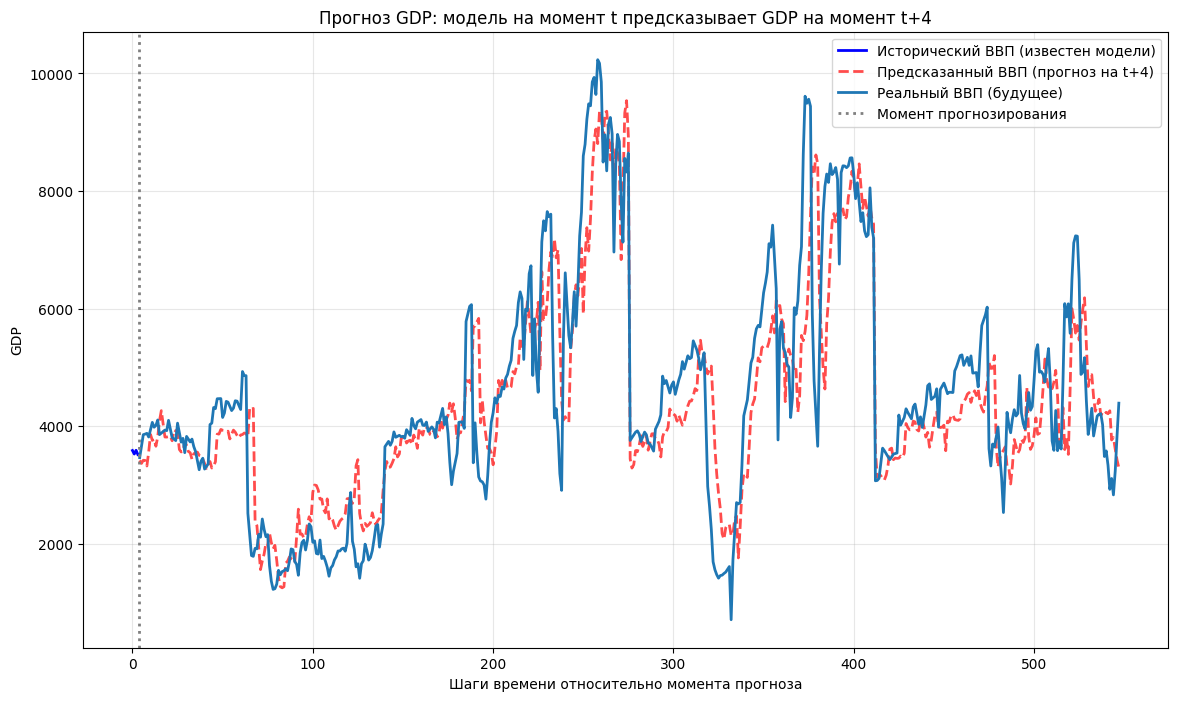

In [89]:
import matplotlib.pyplot as plt

test_prepared = pipe.named_steps["Data_prepare"].transform(test)
historical_gdp = np.expm1(test_prepared["gdp"][:shift])
hist_indices = np.arange(len(historical_gdp))

future_indices = np.arange(shift, shift + len(prediction))

plt.figure(figsize=(14, 8))

plt.plot(hist_indices, historical_gdp, 'b-', 
         label="Исторический ВВП (известен модели)", linewidth=2)

plt.plot(future_indices, np.expm1(prediction), "r--", 
         label=f"Предсказанный ВВП (прогноз на t+{shift})", alpha=0.7, linewidth=2)

plt.plot(future_indices, np.expm1(y_test), 
         label="Реальный ВВП (будущее)", linewidth=2) 

# plt.plot(future_indices, y_baseline[420:], 'g:', 
#          label="Baseline прогноз", linewidth=2, alpha=0.7)

plt.axvline(x=shift-0.5, color='gray', linestyle=':', 
            label='Момент прогнозирования', linewidth=2)

plt.xlabel("Шаги времени относительно момента прогноза")
plt.ylabel("GDP")
plt.legend()
plt.title(f"Прогноз GDP: модель на момент t предсказывает GDP на момент t+{shift}")
plt.grid(True, alpha=0.3)
plt.show()

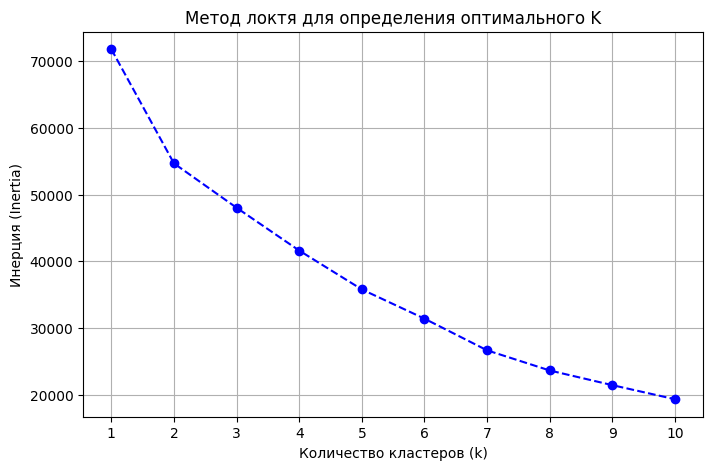

In [90]:
X = pipe.named_steps["Data_prepare"].transform(data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[cluster_cols])

inertia = []
k_range = range(1, 11) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Метод локтя для определения оптимального K')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Инерция (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [91]:
for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"Для k = {k}, средний silhouette score: {silhouette_avg:.4f}")

Для k = 2, средний silhouette score: 0.2766
Для k = 3, средний silhouette score: 0.2924
Для k = 4, средний silhouette score: 0.2939
Для k = 5, средний silhouette score: 0.2961


In [92]:
import shap

In [93]:
X_test_prepared = pipe.named_steps["Data_prepare"].transform(test)
X_test_clustered = pipe.named_steps["Clusterisation"].transform(X_test_prepared)
X_test = pipe.named_steps["Data_select"].transform(X_test_clustered)

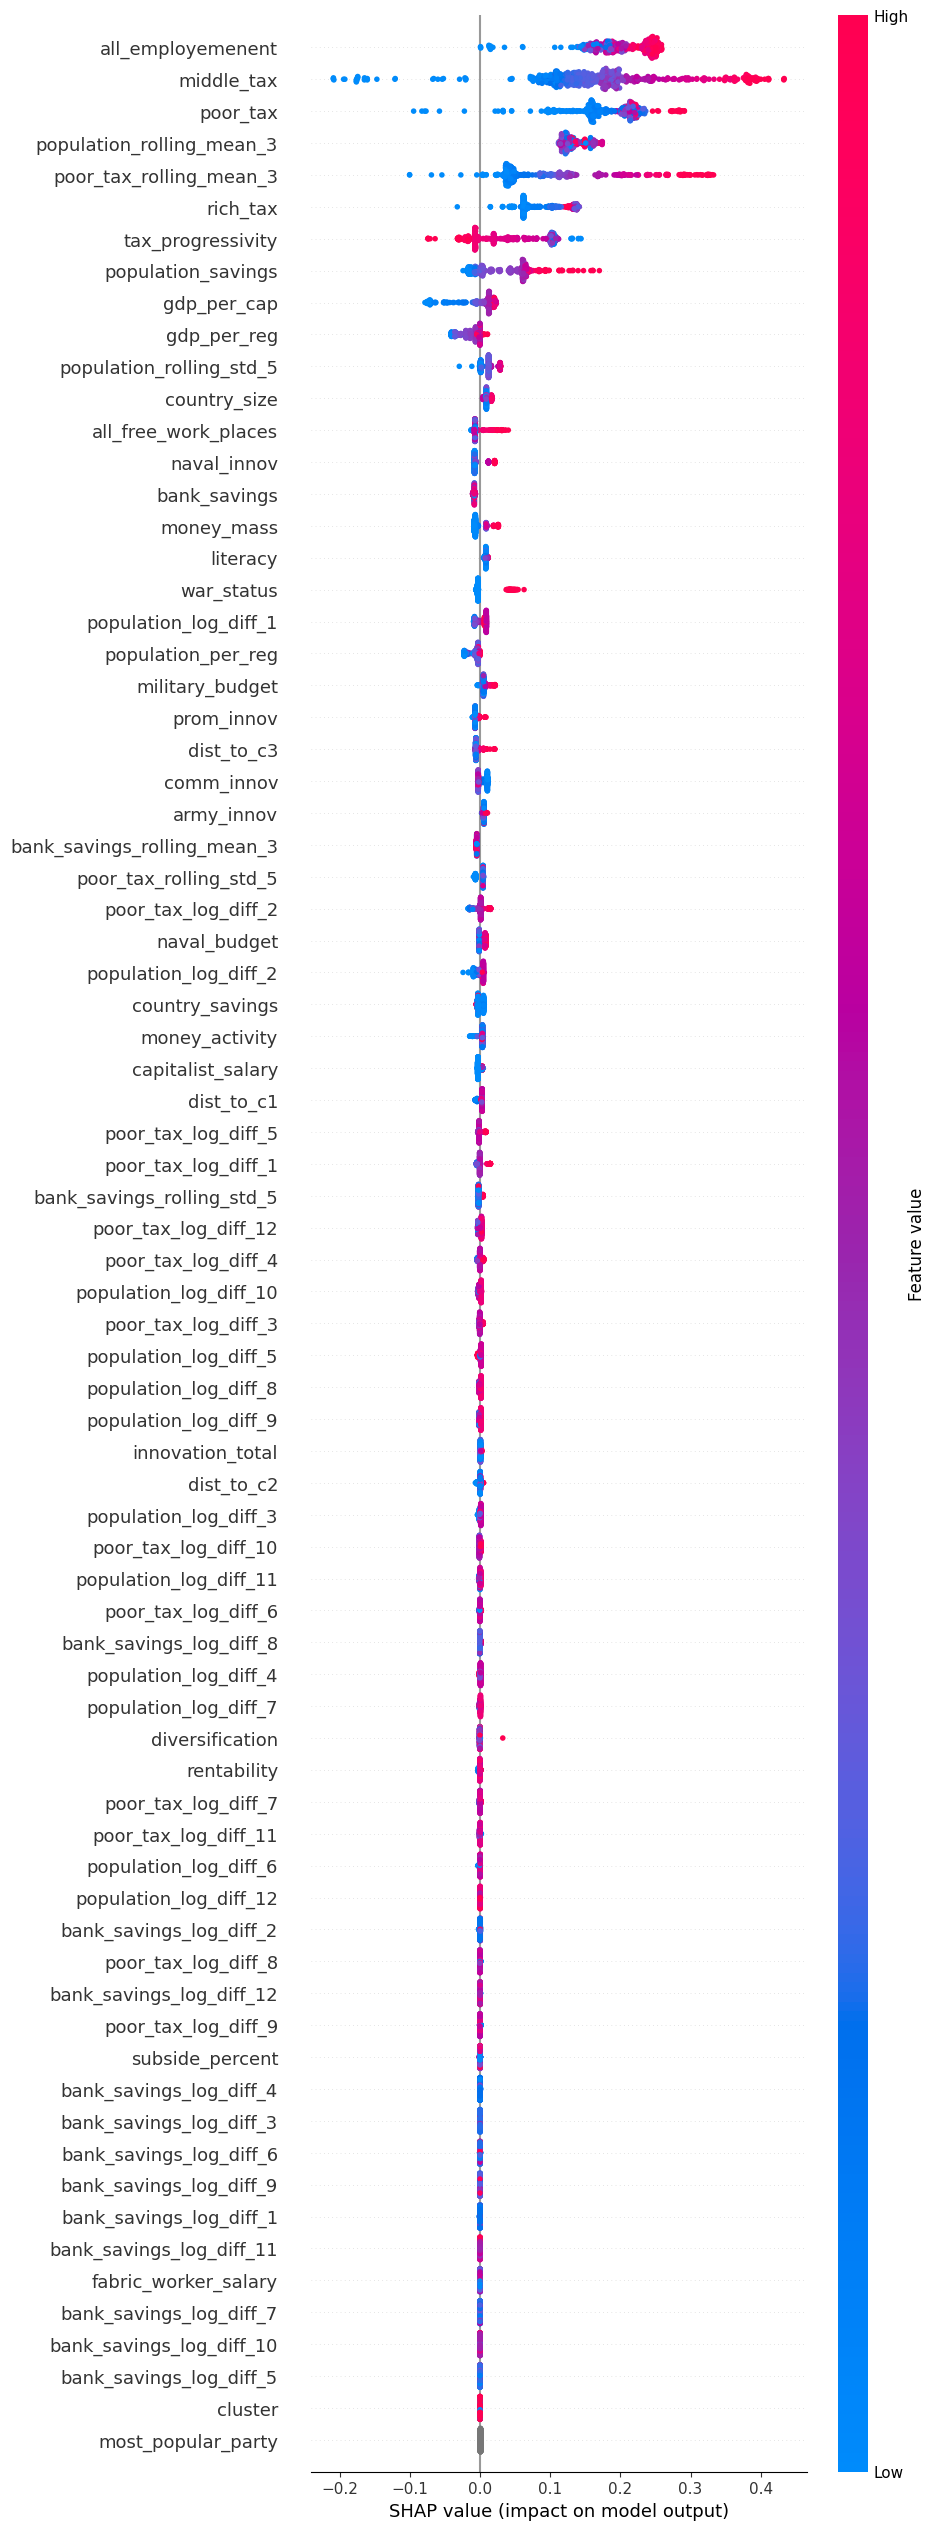

In [ ]:
model = pipe.named_steps["Model"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values, 10)

In [95]:
stats = Stats(pipe, data)
stats.model_score()

MAE: 393.36145570337237
MSE: 726848.7474898545
RMSE: 852.5542490011146


In [96]:
stats.get_clusters_info("lite_explain")
stats.get_clusters_info("normal")

Cluster 1: industrialized
Cluster 2: mixed economy
Cluster 3: mixed economy

Cluster 1 (39 элементов):
AUS (1874-1885) AUS (1886-1895) AUS (1896-1906) BEL (1851-1862) BEL (1863-1873) BEL (1874-1885) BEL (1886-1895) BEL (1896-1906) ENG (1836-1850) ENG (1851-1862) ENG (1863-1873) ENG (1874-1885) ENG (1886-1895) ENG (1896-1906) FRA (1836-1850) FRA (1851-1862) FRA (1863-1873) FRA (1874-1885) FRA (1886-1895) FRA (1896-1906) MEX (1896-1906) PER (1896-1906) PRU (1851-1862) PRU (1863-1873) PRU (1874-1885) PRU (1886-1895) PRU (1896-1906) RUS (1896-1906) SIC (1886-1895) SIC (1896-1906) SWE (1851-1862) SWE (1863-1873) SWE (1874-1885) SWE (1886-1895) SWE (1896-1906) USA (1863-1873) USA (1874-1885) USA (1886-1895) USA (1896-1906) 
Cluster 2 (6 элементов):
CHI (1836-1850) CHI (1851-1862) CHI (1863-1873) CHI (1874-1885) CHI (1886-1895) CHI (1896-1906) 
Cluster 3 (45 элементов):
AFG (1836-1850) AFG (1851-1862) AFG (1863-1873) AFG (1874-1885) AFG (1886-1895) AFG (1896-1906) AUS (1836-1850) AUS (1851-18

In [97]:
stats.cross_val_score(data=data, y=y, groups=groups, logging=True)

=====================Timeseries Cross Validation======================
Тест на файле 4 (Фолд 1): MAE = 499.92, RMSE = 787.42
Тест на файле 1 (Фолд 2): MAE = 830.39, RMSE = 1601.09
Тест на файле 2 (Фолд 3): MAE = 1043.29, RMSE = 2227.72
Тест на файле 0 (Фолд 4): MAE = 642.00, RMSE = 1215.13
Тест на файле 5 (Фолд 5): MAE = 606.34, RMSE = 1189.14
==============================Результаты==============================
Средний MAE: 724.39 (+/- 191.86)
Средний MSE: 2207362.50 (+/- 1510090.33)
Средний RMSE: 1404.10 (+/- 485.67)


In [98]:
scaler = pipe.named_steps["Clusterisation"].scaler
stats.get_clusters_info("hard_explain", scaler=scaler)

[[ 2.97248309e+01  3.99680289e-14  5.01803431e+00  6.49686275e+00
  -7.10542736e-14 -1.49213975e-13 -2.62900812e-13 -4.73259465e+02
   1.77635684e-15  9.43689571e-16 -1.09139364e-11  1.60406660e+07]
 [ 4.26372345e+00  6.39279778e+00  1.16764354e+01  5.25523500e+01
   3.00784857e+01  2.78439520e+01  5.79224377e+01 -1.39879385e+03
   2.44364543e+01  7.18843490e-01  3.73393645e+03  1.84136018e+06]
 [ 2.28005437e+01  2.83422497e+00  4.38208916e+00  2.40903064e+01
   1.23566529e+01  1.18591678e+01  2.42158208e+01 -2.56737410e+02
   7.92840192e+00  3.54609511e-01  1.72064678e+02  1.28717598e+06]]


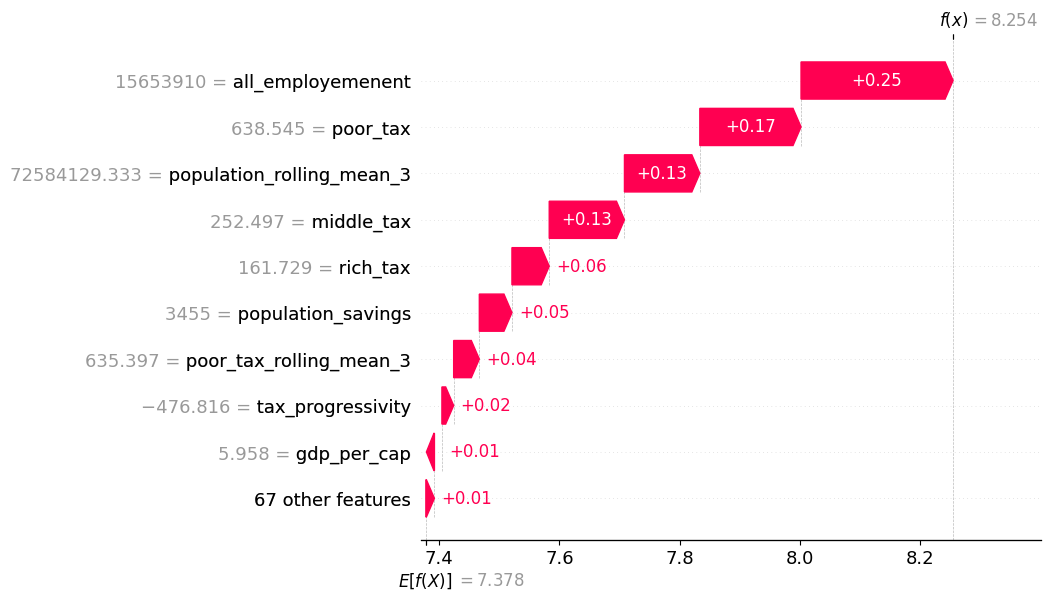

In [99]:
shap.plots.waterfall(shap_values[54])